In [1]:
# Install qcirclab from the companion repository
!pip install -q git+https://github.com/2forts/qcirclab_repo.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, floor, gcd, ceil
from fractions import Fraction

from qcirclab import Circuit
import qcirclab.gates as qg

In [3]:
def plot_counts(counts, title=None):
    """Simple histogram for qcirclab measurement counts."""
    if not counts:
        print("No counts to plot")
        return
    labels = sorted(counts.keys())
    values = [counts[k] for k in labels]
    plt.figure(figsize=(max(5, 0.5*len(labels)), 3))
    plt.bar(labels, values)
    plt.xlabel("bitstring")
    plt.ylabel("counts")
    if title:
        plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def pretty_state(state, n_qubits=None, atol=1e-10):
    """Print nonzero amplitudes in computational-basis notation."""
    state = np.asarray(state, dtype=complex).reshape(-1)
    if n_qubits is None:
        n_qubits = int(np.log2(state.size))
    terms = []
    for i, amp in enumerate(state):
        if abs(amp) > atol:
            terms.append(f"({amp:.3g})|{i:0{n_qubits}b}>")
    return " + ".join(terms) if terms else "0"


def dominant_basis_state(state, atol=1e-10):
    """Return the basis label with largest probability."""
    state = np.asarray(state, dtype=complex)
    n = int(np.log2(state.size))
    idx = int(np.argmax(np.abs(state)**2))
    prob = float(abs(state[idx])**2)
    if prob < atol:
        return None, prob
    return format(idx, f"0{n}b"), prob


def circuit_unitary(qc: Circuit) -> np.ndarray:
    """Compute the full unitary matrix of a measurement-free circuit."""
    n = qc.n_qubits
    U = np.zeros((2**n, 2**n), dtype=complex)
    for j in range(2**n):
        basis = np.zeros(2**n, dtype=complex)
        basis[j] = 1.0
        tmp = qc.copy().set_statevector(basis)
        U[:, j] = tmp.statevector()
    return U


def bits_of(index, n_bits):
    return [int(b) for b in format(index, f"0{n_bits}b")]


def index_from_bits(bits):
    return int("".join(str(int(b)) for b in bits), 2)


def bits_to_int_lsb_first(bits):
    return sum(int(bit) << i for i, bit in enumerate(bits))


def set_register_int(bits, qubits, value, lsb_first=True):
    for i, q in enumerate(qubits):
        bit = (value >> i) & 1 if lsb_first else (value >> (len(qubits)-1-i)) & 1
        bits[q] = bit


def permutation_unitary(n_qubits, mapping):
    dim = 2**n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    seen = set()
    for j in range(dim):
        k = mapping(j)
        if k < 0 or k >= dim:
            raise ValueError("mapping produced an invalid basis index")
        if k in seen:
            raise ValueError("mapping is not reversible/permutational")
        seen.add(k)
        U[k, j] = 1.0
    return U


def sample_counts_from_statevector(state, measured_qubits=None, shots=1024, seed=None):
    """Sample measurement counts from a statevector without re-running the circuit per shot."""
    state = np.asarray(state, dtype=complex).reshape(-1)
    n_qubits = int(np.log2(state.size))
    if measured_qubits is None:
        measured_qubits = list(range(n_qubits))
    measured_qubits = list(measured_qubits)

    probs = {}
    for idx, amp in enumerate(state):
        p = float(abs(amp)**2)
        if p <= 1e-15:
            continue
        bits = format(idx, f"0{n_qubits}b")
        key = "".join(bits[q] for q in measured_qubits)
        probs[key] = probs.get(key, 0.0) + p

    labels = sorted(probs.keys())
    pvals = np.array([probs[k] for k in labels], dtype=float)
    pvals = pvals / pvals.sum()
    rng = np.random.default_rng(seed)
    samples = rng.multinomial(shots, pvals)
    return {label: int(count) for label, count in zip(labels, samples) if count}


# Subsection 5.2.5 **Implementations and visualization**

q0: |0>───  [ H ]───  ─●─[ H ]─M─
q1: |0>[ X ]───  [ H ]─X────  ───
c0:  0                        ═╩═
{'1': 1024}


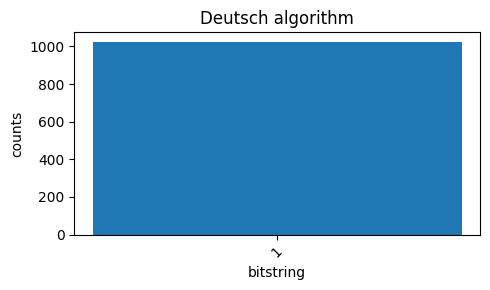

In [4]:
# Deutsch algorithm

oracle_type = "balanced"  # "balanced", "constant_0", or "constant_1"

qc = Circuit(2, 1)
qc.x(1)               # prepare |1> on the oracle target
qc.h(0).h(1)          # create superposition

if oracle_type == "balanced":
    qc.cx(0, 1)       # f(x)=x oracle
elif oracle_type == "constant_1":
    qc.x(1)           # f(x)=1 oracle

qc.h(0)
qc.measure(0, 0)

print(qc.draw())
counts = qc.run(shots=1024, seed=7).counts
print(counts)
plot_counts(counts, title="Deutsch algorithm")

q0: |0>───  [ H ]───  ───  ───  ─●───────[ H ]─M────  ──────  ───
q1: |0>───  ───  [ H ]───  ───  ────●───────  ───[ H ]─M────  ───
q2: |0>───  ───  ───  [ H ]───  ───────●────  ──────  ───[ H ]─M─
q3: |0>[ X ]───  ───  ───  [ H ]─X──X──X────  ──────  ──────  ───
c0:  0                                        ═╩═     ═══     ═══
c1:  0                                        ═══     ═╩═     ═══
c2:  0                                        ═══     ═══     ═╩═
{'111': 1024}


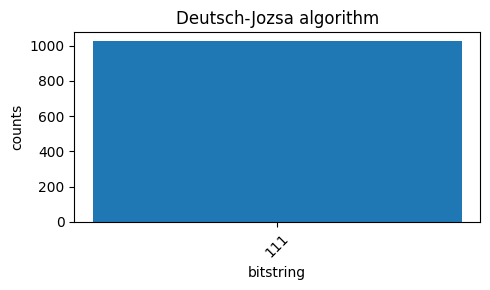

In [5]:
# Deutsch-Jozsa algorithm

def deutsch_jozsa_oracle(n, ftype="balanced"):
    oracle = Circuit(n + 1)
    anc = n
    if ftype == "balanced":
        for qubit in range(n):
            oracle.cx(qubit, anc)
    elif ftype == "constant_1":
        oracle.x(anc)
    elif ftype == "constant_0":
        pass
    else:
        raise ValueError("ftype must be balanced, constant_0, or constant_1")
    return oracle

n = 3
qc = Circuit(n + 1, n)
anc = n
qc.x(anc)
for q in range(n + 1):
    qc.h(q)
qc.compose(deutsch_jozsa_oracle(n, "balanced"))
for q in range(n):
    qc.h(q).measure(q, q)

print(qc.draw())
counts = qc.run(shots=1024, seed=8).counts
print(counts)
plot_counts(counts, title="Deutsch-Jozsa algorithm")

q0: |0>───  [ H ]───  ───  ───  ───  ─●───────[ H ]─M────  ──────  ──────  ───
q1: |0>───  ───  [ H ]───  ───  ───  ────────────  ───[ H ]─M────  ──────  ───
q2: |0>───  ───  ───  [ H ]───  ───  ────●───────  ──────  ───[ H ]─M────  ───
q3: |0>───  ───  ───  ───  [ H ]───  ───────●────  ──────  ──────  ───[ H ]─M─
q4: |0>[ X ]───  ───  ───  ───  [ H ]─X──X──X────  ──────  ──────  ──────  ───
c0:  0                                             ═╩═     ═══     ═══     ═══
c1:  0                                             ═══     ═╩═     ═══     ═══
c2:  0                                             ═══     ═══     ═╩═     ═══
c3:  0                                             ═══     ═══     ═══     ═╩═
secret: 1011
{'1011': 1024}


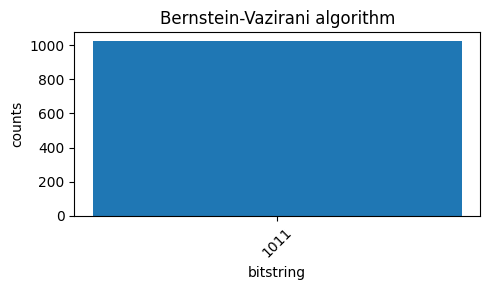

In [6]:
# Bernstein-Vazirani algorithm

secret = "1011"
n = len(secret)
anc = n

qc = Circuit(n + 1, n)
qc.x(anc)
for q in range(n + 1):
    qc.h(q)

for j, bit in enumerate(secret):
    if bit == "1":
        qc.cx(j, anc)

for q in range(n):
    qc.h(q).measure(q, q)

print(qc.draw())
counts = qc.run(shots=1024, seed=9).counts
print("secret:", secret)
print(counts)
plot_counts(counts, title="Bernstein-Vazirani algorithm")

# Subsection 5.3.3 **Implementation**

In [7]:
def qft_circuit(n, include_swaps=True):
    qc = Circuit(n, name="QFT")
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            angle = np.pi / 2**(k - j)
            qc.cp(angle, k, j)
    if include_swaps:
        for j in range(n // 2):
            qc.swap(j, n - j - 1)
    return qc

n = 3
qc = qft_circuit(n)
print(qc.draw())
print("Gate counts:", qc.count_ops())
print("Depth:", qc.depth())

q0: |0>[ H ][ CP][ CP]───  ───  ───  ─x─
q1: |0>───  ─●─  ───  [ H ][ CP]───  ───
q2: |0>───  ───  ─●─  ───  ─●─  [ H ]─x─
Gate counts: {'h': 3, 'cp': 3, 'swap': 1}
Depth: 6


In [8]:
# Apply QFT to a computational basis state

n = 3
initial = "101"
qc = Circuit(n).initialize_basis(initial)
qc.compose(qft_circuit(n))

state = qc.statevector()
print("Input:", initial)
print("QFT output:")
print(pretty_state(state))

Input: 101
QFT output:
(0.354+0j)|000> + (-0.25-0.25j)|001> + (2.16e-17+0.354j)|010> + (0.25-0.25j)|011> + (-0.354+0j)|100> + (0.25+0.25j)|101> + (-2.16e-17-0.354j)|110> + (-0.25+0.25j)|111>


In [9]:
def qft_approx(n, threshold=1e-2, include_swaps=True):
    qc = Circuit(n, name="ApproxQFT")
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            angle = np.pi / 2**(k - j)
            if angle > threshold:
                qc.cp(angle, k, j)
    if include_swaps:
        for j in range(n // 2):
            qc.swap(j, n - j - 1)
    return qc

qc_exact = qft_circuit(5)
qc_approx = qft_approx(5, threshold=0.4)

print("Exact QFT counts:", qc_exact.count_ops(), "depth:", qc_exact.depth())
print("Approx QFT counts:", qc_approx.count_ops(), "depth:", qc_approx.depth())
print(qc_approx.draw())

Exact QFT counts: {'h': 5, 'cp': 10, 'swap': 2} depth: 10
Approx QFT counts: {'h': 5, 'cp': 7, 'swap': 2} depth: 10
q0: |0>[ H ][ CP][ CP]───  ───  ───  ───  ───  ───  ───  ───  ───  ─x────
q1: |0>───  ─●─  ───  [ H ][ CP][ CP]───  ───  ───  ───  ───  ───  ────x─
q2: |0>───  ───  ─●─  ───  ─●─  ───  [ H ][ CP][ CP]───  ───  ───  ──────
q3: |0>───  ───  ───  ───  ───  ─●─  ───  ─●─  ───  [ H ][ CP]───  ────x─
q4: |0>───  ───  ───  ───  ───  ───  ───  ───  ─●─  ───  ─●─  [ H ]─x────


# Subsection 5.3.4 **Inverse QFT and applications**

In [10]:
def iqft_circuit(n, include_swaps=True):
    qc = Circuit(n, name="IQFT")
    if include_swaps:
        for j in range(n // 2):
            qc.swap(j, n - j - 1)
    for j in reversed(range(n)):
        for k in reversed(range(j + 1, n)):
            angle = -np.pi / 2**(k - j)
            qc.cp(angle, k, j)
        qc.h(j)
    return qc

n = 3
qc = Circuit(n).initialize_basis("101")
qc.compose(qft_circuit(n))
qc.compose(iqft_circuit(n))

print("After QFT followed by IQFT:")
print(pretty_state(qc.statevector()))

After QFT followed by IQFT:
(1+0j)|101>


# Subsection 5.4.4 **Implementation example**

q0: |0>───  [ H ]───  ───  ───  ─●─  ───  ───  ───  ─x───────  ───  ───  ───  ───  ───  [ CP][ CP][ CP][ H ]─M──────────
q1: |0>───  ───  [ H ]───  ───  ───  ─●─  ───  ───  ────x────  ───  ───  [ CP][ CP][ H ]───  ───  ─●─  ───  ────M───────
q2: |0>───  ───  ───  [ H ]───  ───  ───  ─●─  ───  ────x────  [ CP][ H ]───  ─●─  ───  ───  ─●─  ───  ───  ───────M────
q3: |0>───  ───  ───  ───  [ H ]───  ───  ───  ─●─  ─x────[ H ]─●─  ───  ─●─  ───  ───  ─●─  ───  ───  ───  ──────────M─
q4: |0>[ X ]───  ───  ───  ───  [U^8][U^4][U^2][U^1]─────────  ───  ───  ───  ───  ───  ───  ───  ───  ───  ────────────
c0:  0                                                                                                      ═╩══════════
c1:  0                                                                                                      ════╩═══════
c2:  0                                                                                                      ═══════╩════
c3:  0                          

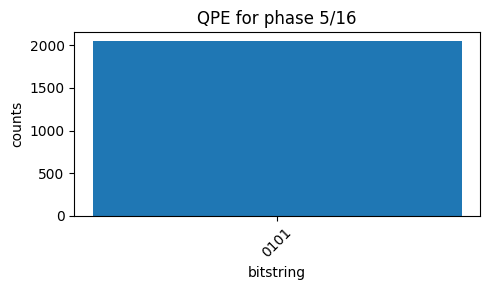

In [11]:
def qpe_phase_gate(phi, t):
    # Estimate the eigenphase of P(2πφ) on eigenstate |1>.
    # Layout: phase register [0..t-1], target qubit t.
    qc = Circuit(t + 1, t)
    target = t

    qc.x(target)
    for q in range(t):
        qc.h(q)

    U = qg.phase(2 * np.pi * phi)
    for k in range(t):
        exponent = 2**(t - 1 - k)
        powered = np.linalg.matrix_power(U, exponent)
        qc.unitary(powered, [target], name=f"U^{exponent}", controls=[k])

    qc.compose(iqft_circuit(t), qubits=range(t))
    for q in range(t):
        qc.measure(q, q)
    return qc

phi = 5/16
t = 4
qpe = qpe_phase_gate(phi, t)

print(qpe.draw())
counts = qpe.run(shots=2048, seed=10).counts
print(counts)
plot_counts(counts, title="QPE for phase 5/16")

# Subsection 5.5.4 **Implementation and simulation**

Marked: 10110
{'10110': 1999, '10100': 1}


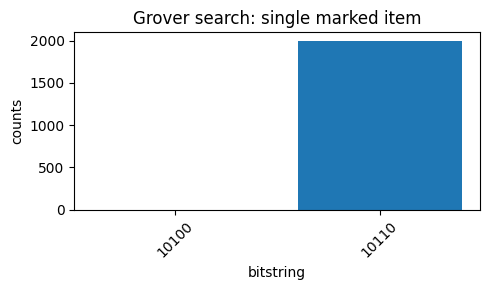

In [12]:
def phase_oracle(n, marks):
    if isinstance(marks, str):
        marks = [marks]
    for bitstr in marks:
        if len(bitstr) != n or set(bitstr) - {"0", "1"}:
            raise ValueError("each mark must be an n-bit string")

    diag = []
    marked = set(marks)
    for idx in range(2**n):
        bitstring = format(idx, f"0{n}b")
        diag.append(-1 if bitstring in marked else 1)

    qc = Circuit(n, name="O_f")
    qc.unitary(np.diag(diag).astype(complex), list(range(n)), name="oracle")
    return qc


def diffuser(n):
    qc = Circuit(n, name="D")
    for q in range(n):
        qc.h(q).x(q)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    for q in range(n):
        qc.x(q).h(q)
    return qc


def grover_iterate(n, marks):
    qc = Circuit(n, name="G")
    qc.compose(phase_oracle(n, marks))
    qc.compose(diffuser(n))
    return qc


def grover_search_state_circuit(n, marks, iters=None):
    if isinstance(marks, str):
        marks = [marks]
    r = len(marks)
    N = 2**n
    k = iters if iters is not None else max(1, floor(pi/4 * sqrt(N / r)))

    qc = Circuit(n)
    for q in range(n):
        qc.h(q)
    G = grover_iterate(n, marks)
    for _ in range(k):
        qc.compose(G)
    return qc

# Example A: single marked item on n=5
n = 5
marked = "10110"
qc_single = grover_search_state_circuit(n, marked)
state_single = qc_single.statevector()
counts_single = sample_counts_from_statevector(state_single, shots=2000, seed=11)
print("Marked:", marked)
print(dict(sorted(counts_single.items(), key=lambda kv: kv[1], reverse=True)[:5]))
plot_counts(counts_single, title="Grover search: single marked item")

Marked: ['01101', '10111']
{'10111': 968, '01101': 961, '00001': 5, '01000': 5, '10000': 5, '10100': 5, '10101': 5, '10110': 5}


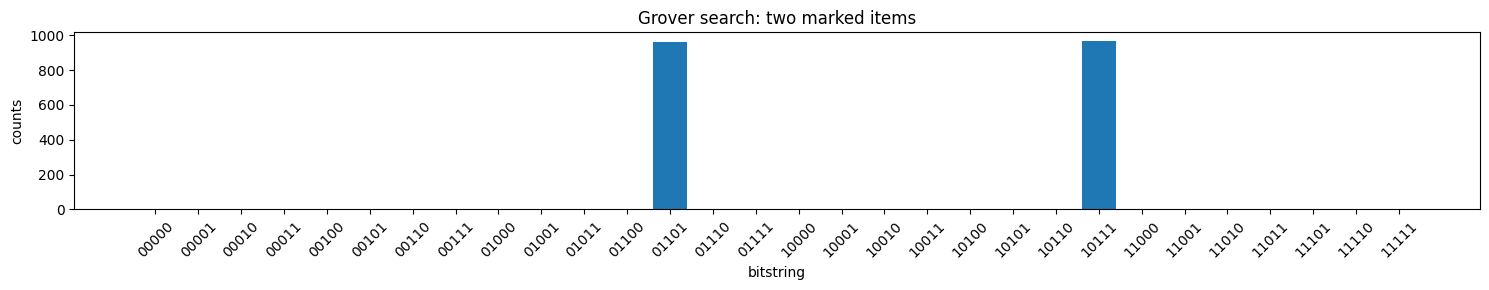

In [13]:
# Example B: two marked items on n=5

marks = ["01101", "10111"]
qc_multi = grover_search_state_circuit(n, marks)
state_multi = qc_multi.statevector()
counts_multi = sample_counts_from_statevector(state_multi, shots=2000, seed=12)
print("Marked:", marks)
print(dict(sorted(counts_multi.items(), key=lambda kv: kv[1], reverse=True)[:8]))
plot_counts(counts_multi, title="Grover search: two marked items")

# Subsection 5.6.6 **Demonstration for small integers**

Top counts: {'1000': 286, '0000': 260, '1100': 244, '0100': 234}
Recovered: {'y': '1100', 'r': 4, 'factors': (3, 5)}


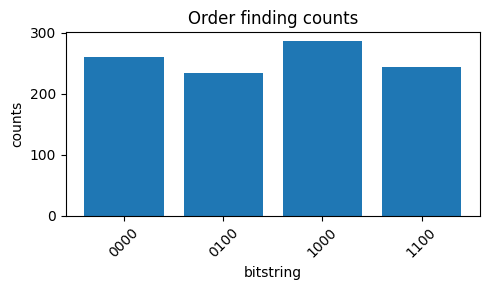

In [14]:
def unitary_modexp_power(a, N, power, n):
    # Permutation matrix on an n-qubit work register.
    # Valid states y<N map to (a^power * y) mod N.
    # Invalid states y>=N are left unchanged.
    dim = 2**n
    ap = pow(a, power, N)
    U = np.zeros((dim, dim), dtype=complex)

    def mapping(index):
        bits = bits_of(index, n)
        y = bits_to_int_lsb_first(bits)
        if y < N:
            y2 = (ap * y) % N
        else:
            y2 = y
        out_bits = bits[:]
        set_register_int(out_bits, range(n), y2, lsb_first=True)
        return index_from_bits(out_bits)

    for j in range(dim):
        U[mapping(j), j] = 1.0
    return U


def qpe_modexp_demo(N=15, a=2, t=4):
    n = int(np.ceil(np.log2(N)))
    total = t + n
    qc = Circuit(total, t)

    phase = list(range(t))
    work = list(range(t, t+n))

    # Initialize work register to |1> using the book/qcirclab register convention.
    bits = [0] * total
    set_register_int(bits, work, 1, lsb_first=True)
    qc.initialize_basis("".join(map(str, bits)))

    for q in phase:
        qc.h(q)

    for j in range(t):
        power = 2**(t - 1 - j)
        U = unitary_modexp_power(a, N, power, n)
        qc.unitary(U, work, name=f"U^{power}", controls=[phase[j]])

    qc.compose(iqft_circuit(t), qubits=phase)

    # Do not add measurements here; we sample the phase register directly
    # from the final statevector to avoid repeated simulation per shot.
    return qc


def continued_fraction_r(y, t, N):
    frac = Fraction(y, 2**t).limit_denominator(N)
    return frac.denominator


def postprocess_find_factors(N, a, counts):
    for y, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
        y_int = int(y, 2)
        t = len(y)
        if y_int == 0:
            continue
        r = continued_fraction_r(y_int, t, N)
        if r % 2 != 0:
            continue
        x = pow(a, r//2, N)
        if x in (1, N-1):
            continue
        p = gcd(x-1, N)
        q = gcd(x+1, N)
        if 1 < p < N and 1 < q < N:
            return {"y": y, "r": r, "factors": tuple(sorted((p, q)))}
    return None

N, a, t = 15, 2, 4
qc = qpe_modexp_demo(N, a, t)
state = qc.statevector()
counts = sample_counts_from_statevector(state, measured_qubits=range(t), shots=1024, seed=13)
factors_info = postprocess_find_factors(N, a, counts)

print("Top counts:", dict(sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:8]))
print("Recovered:", factors_info)
plot_counts(counts, title="Order finding counts")

In [15]:
# Classical reference for the modular powers used above

def modular_exponentiation_reference(base, exponent, modulus):
    result = 1
    power = base % modulus
    e = exponent
    while e:
        if e & 1:
            result = (result * power) % modulus
        power = (power * power) % modulus
        e >>= 1
    return result

base = 2
modulus = 15
for exponent in range(8):
    print(f"{base}^{exponent} mod {modulus} =",
          modular_exponentiation_reference(base, exponent, modulus))

2^0 mod 15 = 1
2^1 mod 15 = 2
2^2 mod 15 = 4
2^3 mod 15 = 8
2^4 mod 15 = 1
2^5 mod 15 = 2
2^6 mod 15 = 4
2^7 mod 15 = 8
